## Data Story Assignment

I chose to look at the Fatal Accidental Overdose dataset (https://data.wprdc.org/dataset/allegheny-county-fatal-accidental-overdoses).

I'll use this notebook to explore the data and create visualizations to represent trends.

In [2]:
# import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# read data
df = pd.read_csv('Fatal Accidental Overdoses.csv')

In [4]:
# view data overview
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 7617 entries, 0 to 7616
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   _id                  7617 non-null   int64  
 1   death_date_and_time  7617 non-null   str    
 2   manner_of_death      7617 non-null   str    
 3   age                  7617 non-null   int64  
 4   sex                  7617 non-null   str    
 5   race                 7613 non-null   str    
 6   case_dispo           7617 non-null   str    
 7   combined_od1         7617 non-null   str    
 8   combined_od2         6159 non-null   str    
 9   combined_od3         4150 non-null   str    
 10  combined_od4         2231 non-null   str    
 11  combined_od5         1004 non-null   str    
 12  combined_od6         385 non-null    str    
 13  combined_od7         160 non-null    str    
 14  combined_od8         47 non-null     str    
 15  combined_od9         15 non-null     str    
 16 

,_id,death_date_and_time,manner_of_death,age,sex,race,case_dispo,combined_od1,combined_od2,combined_od3,combined_od4,combined_od5,combined_od6,combined_od7,combined_od8,combined_od9,combined_od10,incident_zip,decedent_zip,case_year
0,12735790,2024-10-28T16:37:00,Accident,31,M,W,MO,"1,1-Difluoroethane",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15227,NaN,2024
1,12735791,2025-06-18T19:42:00,Accident,40,M,W,MO,"1,1-Difluoroethane",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15213,NaN,2025
2,12735792,2018-01-30T13:15:00,Accident,37,M,W,MO,"1,1-Difluoroethane",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15239,NaN,2018
3,12735793,2019-10-31T20:10:00,Accident,32,M,B,MO,4-fluoro-MDMB-BINACA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15132,NaN,2019
4,12735794,2019-08-26T13:24:00,Accident,38,F,W,MO,4-fluoro-MDMB-BINACA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15222,NaN,2019


Null values seem to fall mainly in the `combined_od` columns.

The zip codes won't be very helpful in visualization because `incident_zip` refers to where the bodies were examined - many of which were out of state & `decedent_zip` has been redacted from the dataset. `decedent_zip` would have been helpful because it would allow analysis into where each accidental overdose (AOD) patient lived.

In [6]:
# drop columns from the dataframe that are unnecessary
df = df.drop(columns=[
    'manner_of_death',      ## all of these are accidental deaths by nature of the dataset
    'case_dispo',           ## all cases are morgue dispositions
    'incident_zip',
    'decedent_zip'
]).copy()

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7617 entries, 0 to 7616
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   _id                  7617 non-null   int64
 1   death_date_and_time  7617 non-null   str  
 2   age                  7617 non-null   int64
 3   sex                  7617 non-null   str  
 4   race                 7613 non-null   str  
 5   combined_od1         7617 non-null   str  
 6   combined_od2         6159 non-null   str  
 7   combined_od3         4150 non-null   str  
 8   combined_od4         2231 non-null   str  
 9   combined_od5         1004 non-null   str  
 10  combined_od6         385 non-null    str  
 11  combined_od7         160 non-null    str  
 12  combined_od8         47 non-null     str  
 13  combined_od9         15 non-null     str  
 14  combined_od10        1 non-null      str  
 15  case_year            7617 non-null   int64
dtypes: int64(3), str(13)
memory usage: 

In [8]:
# modify data types

# modify death_date_and_time column to datetime dtype
df['death_date_and_time'] = pd.to_datetime(df['death_date_and_time'])

# make case_year a str
df['case_year'] = df['case_year'].astype('str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7617 entries, 0 to 7616
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   _id                  7617 non-null   int64         
 1   death_date_and_time  7617 non-null   datetime64[us]
 2   age                  7617 non-null   int64         
 3   sex                  7617 non-null   str           
 4   race                 7613 non-null   str           
 5   combined_od1         7617 non-null   str           
 6   combined_od2         6159 non-null   str           
 7   combined_od3         4150 non-null   str           
 8   combined_od4         2231 non-null   str           
 9   combined_od5         1004 non-null   str           
 10  combined_od6         385 non-null    str           
 11  combined_od7         160 non-null    str           
 12  combined_od8         47 non-null     str           
 13  combined_od9         15 non-null     str    

### Univariate Visualizations

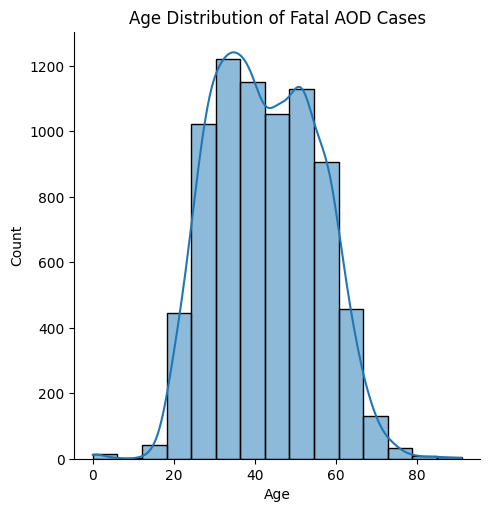

In [11]:
# age
sns.displot(data=df,
            x='age',
            kind='hist',
            bins=15,
           kde=True)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution of Fatal AOD Cases')
plt.show()

Most cases were adults between 30-60, with peaks in distributions around 35 and 50 years of age.

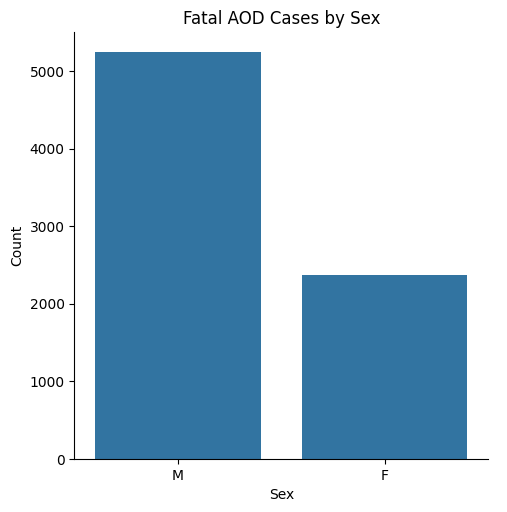

In [13]:
# sex
sns.catplot(data=df,
           x='sex',
           kind='count')
plt.title('Fatal AOD Cases by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

Much higher incidence of males vs. females. Males seem to account for 2/3 of cases.

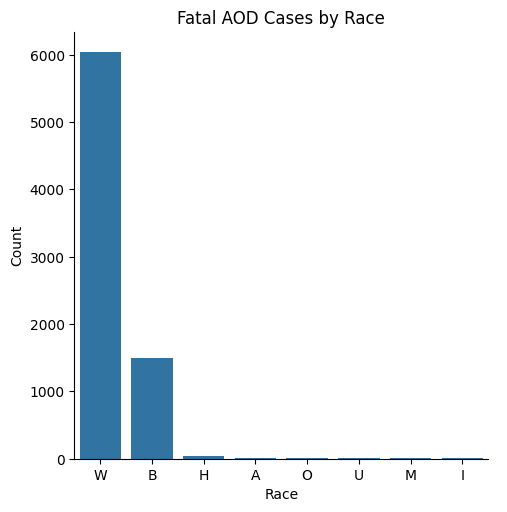

In [15]:
# race
sns.catplot(data=df,
           x='race',
           kind='count')
plt.title('Fatal AOD Cases by Race')
plt.xlabel('Race')
plt.ylabel('Count')
plt.show()

White people hevaily outweigh other racial groups as the predominant victim in fatal AOD cases.

This aligns with US Census data, which in 2025 reported that 79% of Allegheny County is White, 14% is Black, and other racial groups makeup the remainder of the population with relatively small percentage shares of the total population.

Source: https://www.census.gov/quickfacts/fact/table/alleghenycountypennsylvania/PST045225

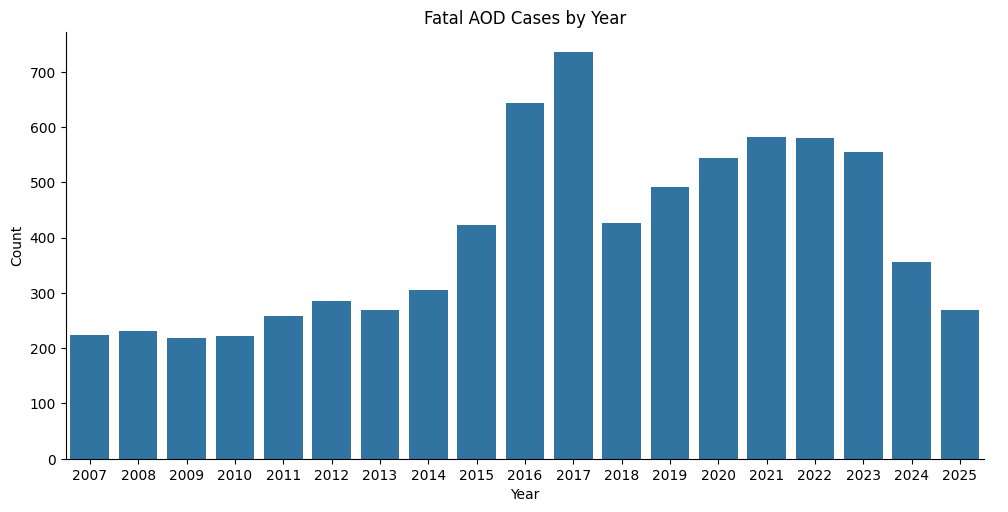

In [17]:
# case_year
sns.catplot(data=df.sort_values(by='case_year'),
           x='case_year',
           kind='count',
           aspect=2)
plt.title('Fatal AOD Cases by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

Cases were relatively stable with a slightly positive slope from 2007-2014, then began to increase rapidly. In 2018, fatal AOD cases dropped significantly, then began to rise again, before falling for three consecutive years from 2023-2025.

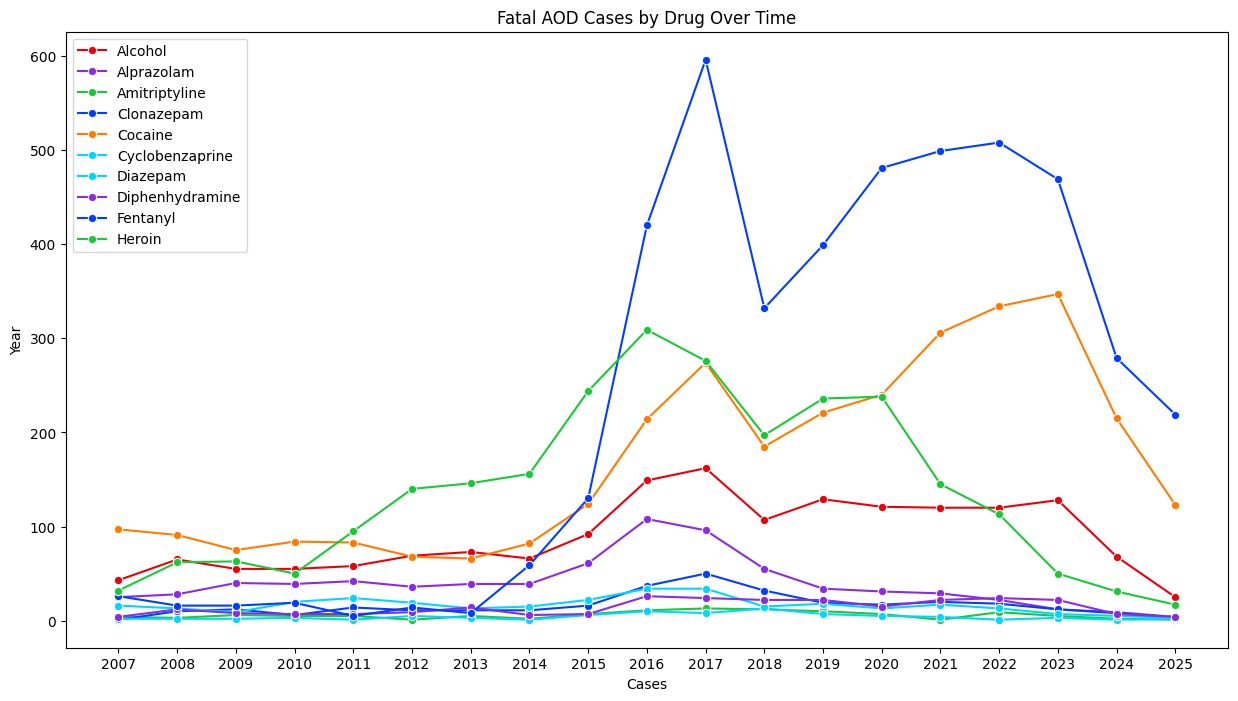

In [105]:
"""
To look at the drugs involved, I'll have to modify the data into long format.
"""
# drug columns
drug_cols = [f'combined_od{i}' for i in range(1, 11)]

# melt drugs in combined_od columns
df_long = df.melt(
    id_vars=['_id', 'death_date_and_time', 'age', 'sex', 'race', 'case_year'],
    value_vars=drug_cols,
    value_name='drug'
)

# remove null drugs
df_long = df_long.dropna(subset=['drug'])

# group fentanyl variants
df_long['drug'] = df_long['drug'].str.replace(r'.*entanyl.*', 'Fentanyl', regex=True)

# get the count for each drug
counts = (
    df_long.groupby(['case_year', 'drug'])['_id']
    .nunique()
    .reset_index(name='n_cases')
)

# determine top drugs overall so palette is consistent
top_drugs_overall = df_long['drug'].value_counts(10).index

# create consistent color palette
colors = sns.color_palette("bright", len(top_drugs_overall))
palette = dict(zip(top_drugs_overall, colors))

# plot the top 10 drugs
plt.figure(figsize=(15, 8))

sns.lineplot(
    data=counts.loc[counts['drug'].isin(counts['drug'].value_counts().head(10).index)],
    x='case_year',
    y='n_cases',
    hue='drug',
    marker='o',
    palette=palette
)

plt.title('Fatal AOD Cases by Drug Over Time')
plt.xlabel('Cases')
plt.ylabel('Year')
plt.legend(loc='best')
plt.show()

The rise of Fentanyl-related cases seems to match up well with the overall trends of total cases.

## Multivariate Analysis

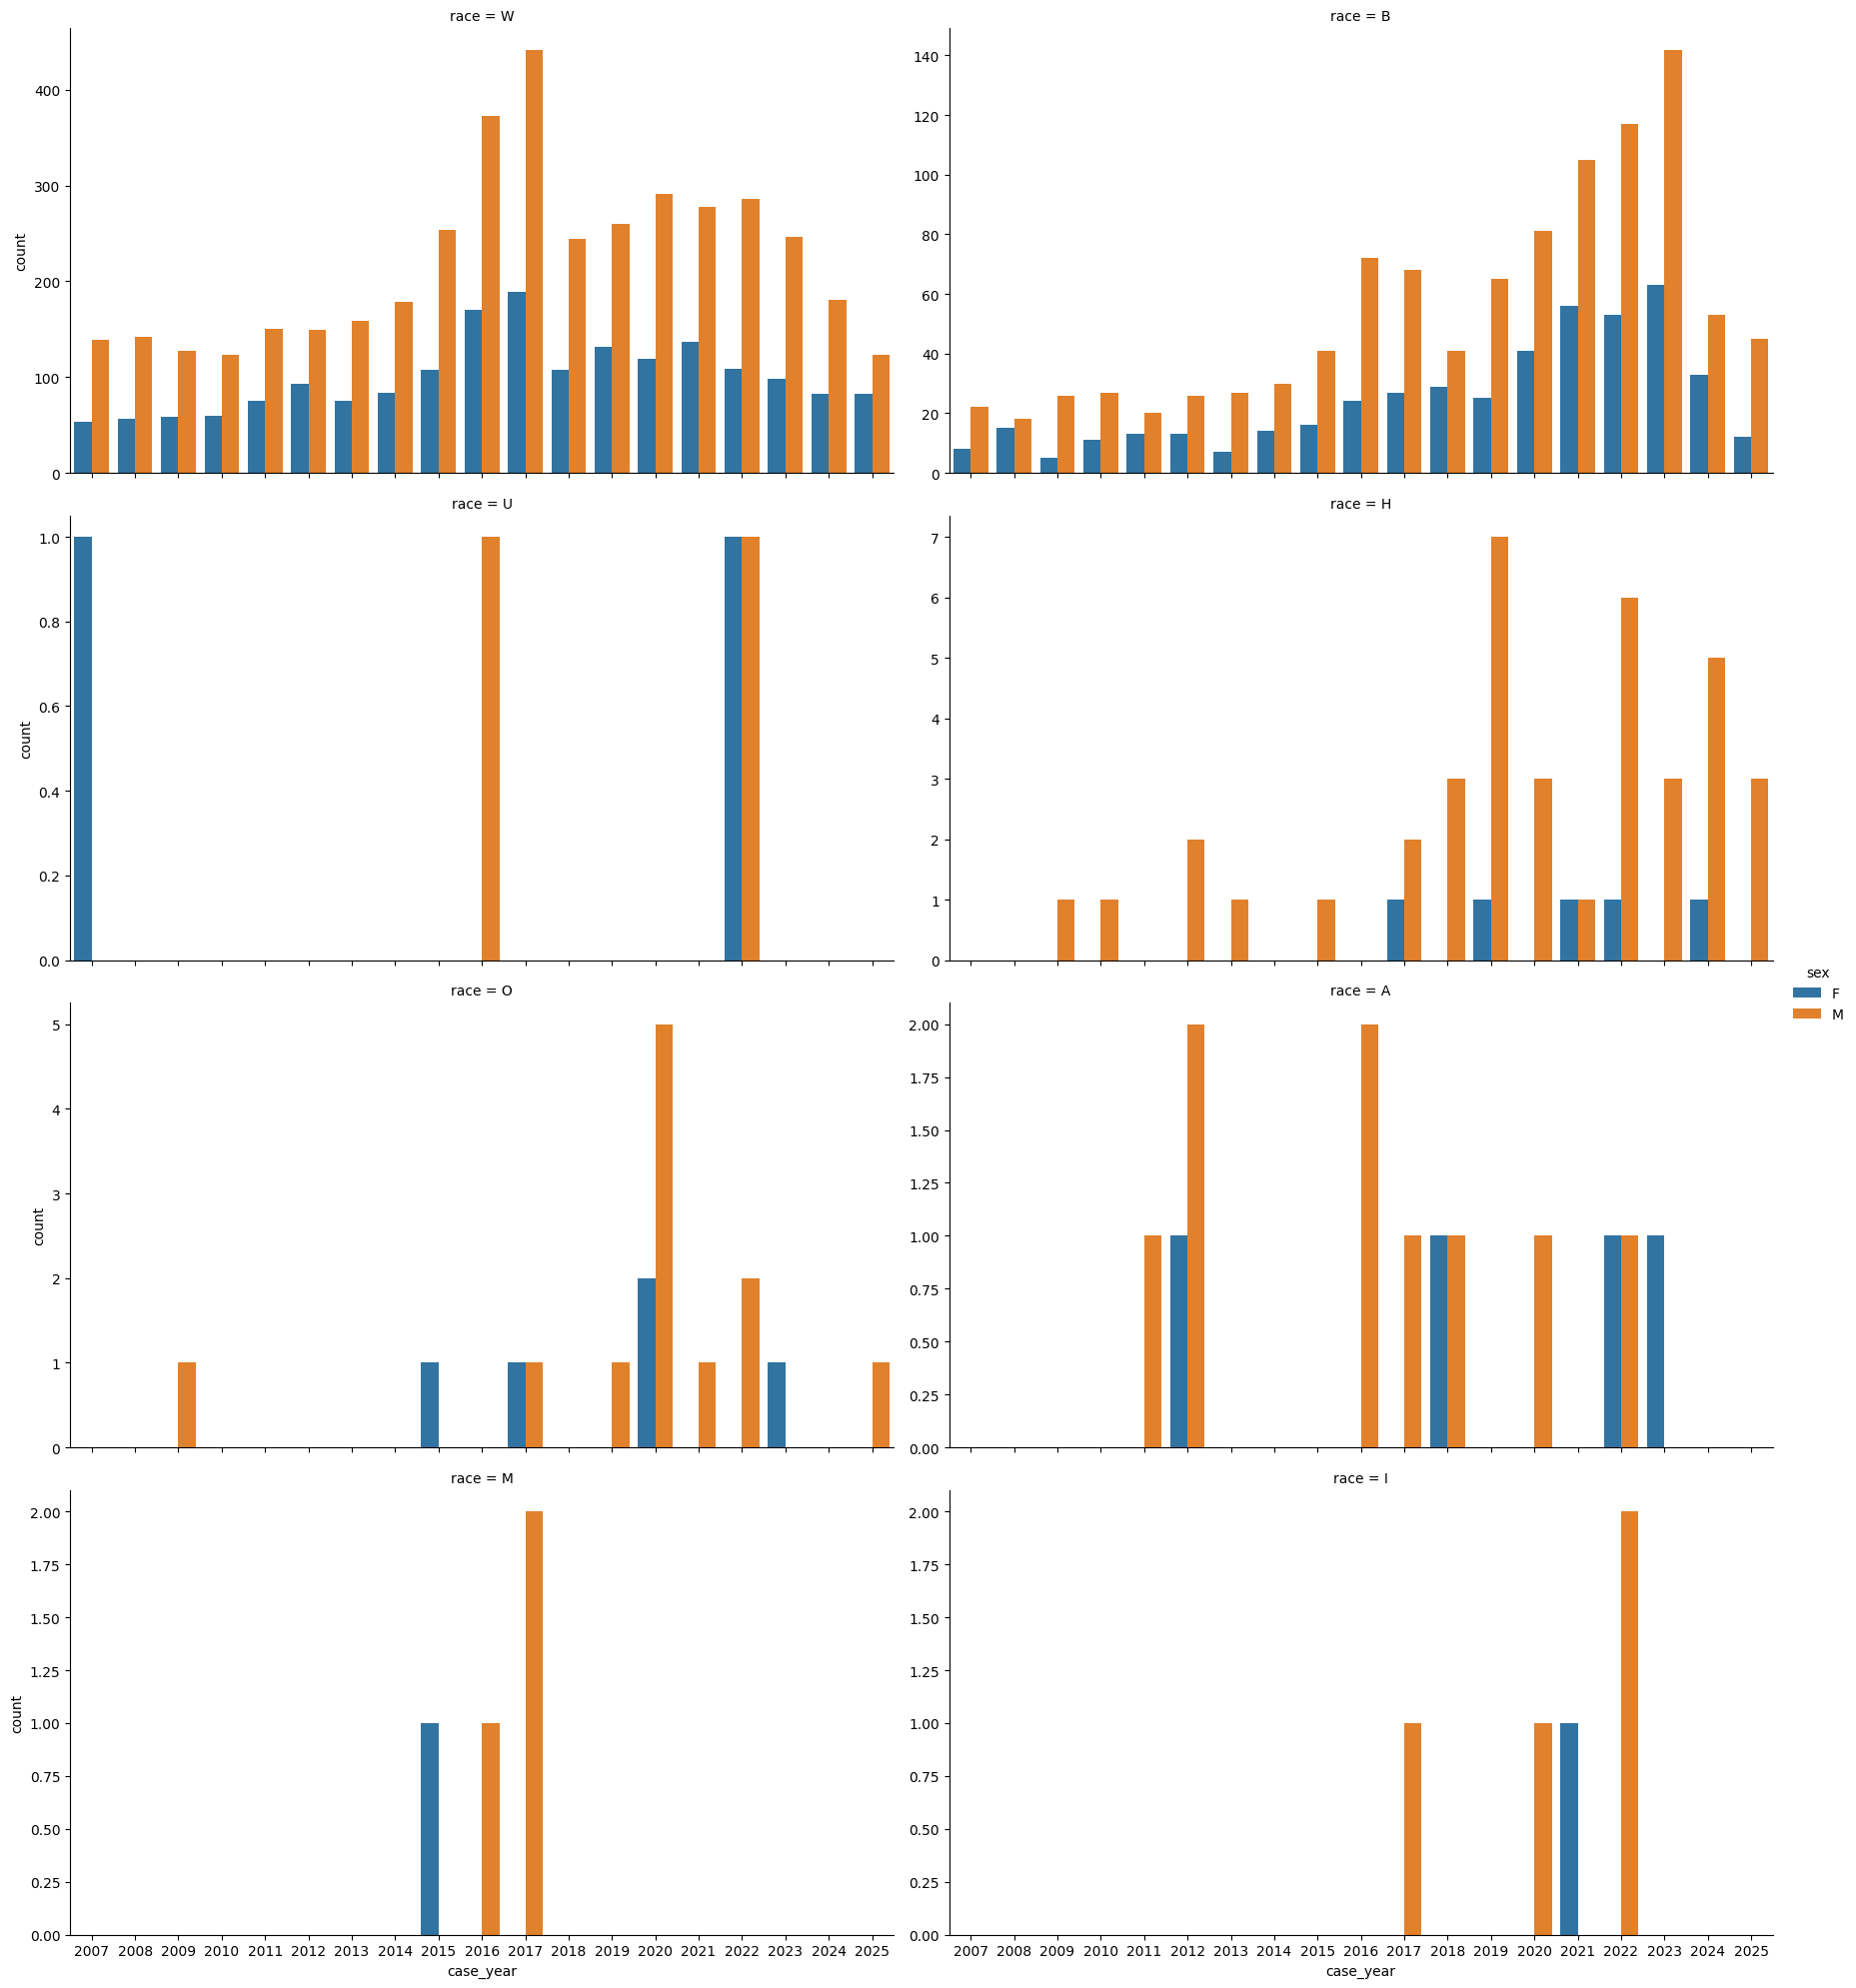

In [22]:
# age, sex, race
sns.catplot(data=df.sort_values(by='case_year'),
           x='case_year', 
           kind='count',
           hue='sex',
            col='race',
            col_wrap=2, 
            sharey=False,
            aspect=1.8)
plt.show()

Racial groups outside of Black and White do not have a significant number of fatal AOD cases per year, most having between 0-5. 

For Whites, cases peak in 2017, then have a steep drop-off, followed by a few years of stagnation, then another drop.

For Blacks, cases do not hit the same drastic peak in 2017. Instead, cases see a smal peak in 2017, drop in 2018 and 2019, then balloon up until a peak is hit in 2023, then drops dramatically in 2024 and 2025. 

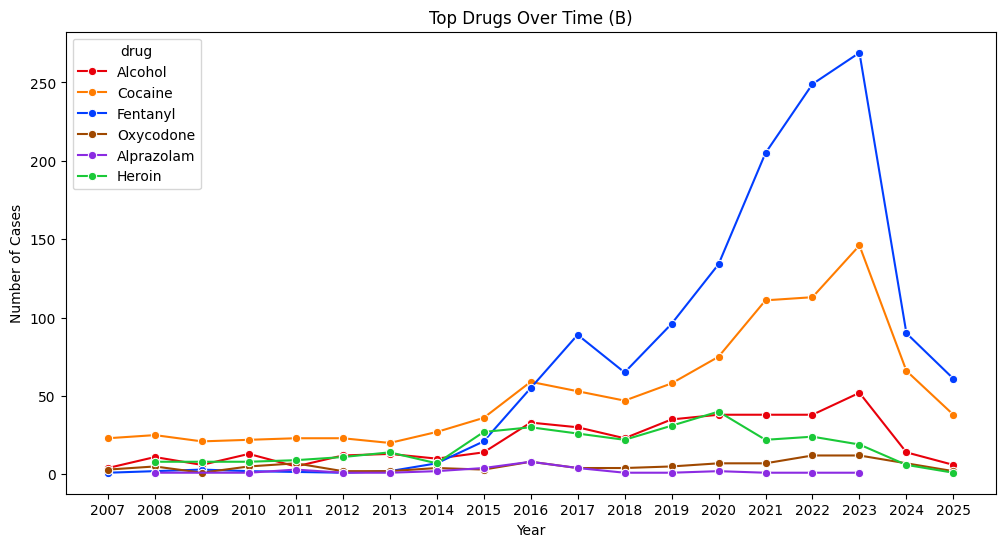

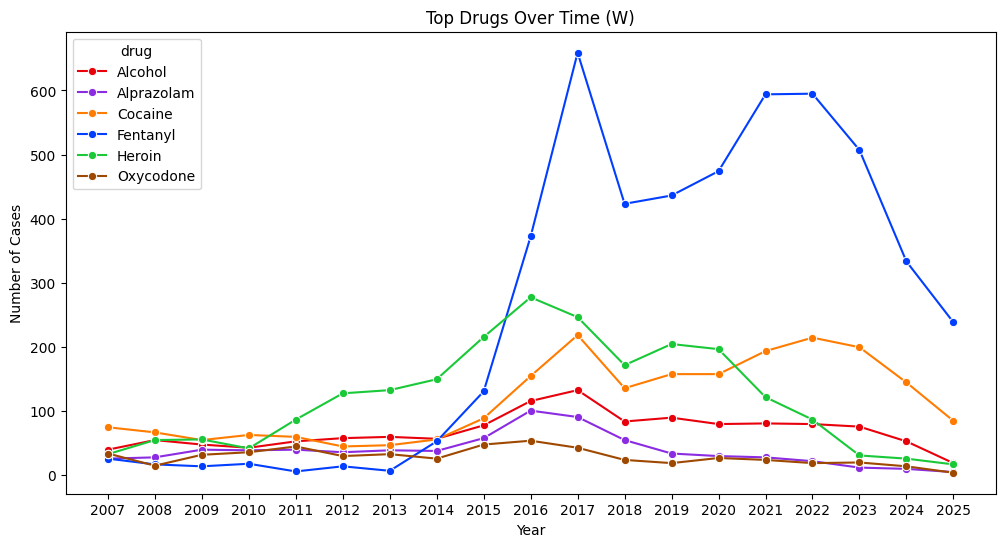

In [107]:
# keep only B and W for race
df_bw = df[df['race'].isin(['B','W'])]

# reshape drugs to long format
df_long = df_bw.melt(
    id_vars=['race', 'case_year'],
    value_vars=drug_cols,
    value_name='drug'
)

# remove null drugs
df_long = df_long.dropna(subset=['drug'])

# group fentanyl variants
df_long['drug'] = df_long['drug'].str.replace(r'.*entanyl.*', 'Fentanyl', regex=True)

# determine top drugs overall so palette is consistent
top_drugs_overall = df_long['drug'].value_counts().head(6).index

for r in ['B', 'W']:

    subset = df_long[df_long['race'] == r]
    subset = subset[subset['drug'].isin(top_drugs_overall)]

    # count occurrences by year and drug
    counts = (
        subset.groupby(['case_year','drug'])
        .size()
        .reset_index(name='count')
    )

    plt.figure(figsize=(12,6))

    sns.lineplot(
        data=counts,
        x='case_year',
        y='count',
        hue='drug',
        palette=palette,
        marker='o'
    )

    plt.title(f'Top Drugs Over Time ({r})')
    plt.xlabel('Year')
    plt.ylabel('Number of Cases')
    plt.show()

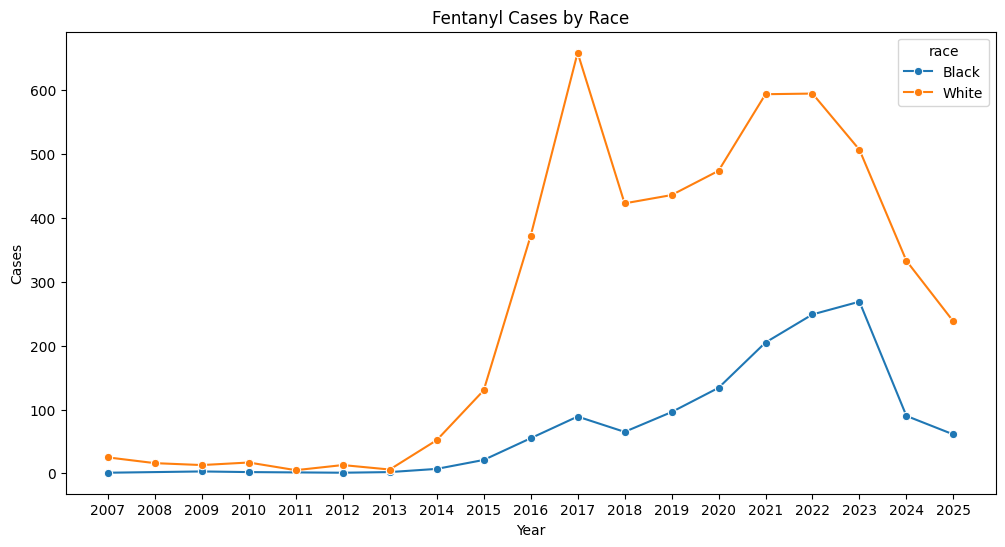

In [189]:
# filter the long format df to only fentanyl-related cases
subset = df_long.loc[df_long['drug'] == 'Fentanyl']

# modify names of races
subset = subset.replace({'race': {'B': 'Black', 'W': 'White'}})

# count occurrences by year and drug
counts = (
    subset.groupby(['case_year','drug', 'race'])
    .size()
    .reset_index(name='count')
)

# plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=counts,
    x='case_year',
    y='count',
    hue='race',
    marker='o'
)
plt.title('Fentanyl Cases by Race')
plt.xlabel('Year')
plt.ylabel('Cases')
plt.show()

From these visualizations, we can see that the spikes in fatal AOD cases coincided with Fentanyl peaks in the White population since they made up the overwhelming majority of the Allegheny County populous. 

In the Black population, Fentanyl-related fatal AOD cases rose over time, spiked in 2023, and saw a very sharp decline thereafter.

Lesser significant trends included the rise of Heroin-related fatal AOD cases in the White population from 2007-2016, and a rise and more sustained period of Cocaine-related fatal AOD cases from 2016-2024. Cocaine-related cases in the Black community followed a similar rise and fall to Fentanyl in the same population.

## Fentanyl Focus
Fentanyl emerged as the the prominent leader in fatal AOD cases and seemed to drive larger trends amongst the data more than any other drug.

In [27]:
# create a dataframe of just fentanyl cases
fentanyl_df = df.loc[(df.combined_od1.str.contains('entanyl', case=False, na=False)) |\
        (df.combined_od2.str.contains('entanyl', case=False, na=False)) |\
        (df.combined_od3.str.contains('entanyl', case=False, na=False)) |\
        (df.combined_od4.str.contains('entanyl', case=False, na=False)) |\
        (df.combined_od5.str.contains('entanyl', case=False, na=False)) |\
        (df.combined_od6.str.contains('entanyl', case=False, na=False)) |\
        (df.combined_od7.str.contains('entanyl', case=False, na=False)) |\
        (df.combined_od8.str.contains('entanyl', case=False, na=False)) |\
        (df.combined_od9.str.contains('entanyl', case=False, na=False)) |\
        (df.combined_od10.str.contains('entanyl', case=False, na=False))
]

In [28]:
# print statistics about the dataframe
print('Total Cases:', df.shape[0])
print('Fentanyl-Related Cases:', fentanyl_df.shape[0])
print('% of Total Cases with Fentanyl listed:', np.round(len(fentanyl_df)/len(df), 3))
print('---------------')
print('Age Statistics of the Fentanyl Case Dataframe:')
print(fentanyl_df.age.describe())
print('---------------')
print('Date & Time Statistics of the Fentanyl Case Dataframe:')
print(fentanyl_df.death_date_and_time.describe())
print('---------------')
print('Race Percentages of the Fentanyl Case Dataframe:')
print(fentanyl_df.race.value_counts(normalize=True))
print('---------------')
print('Sex Percentages of the Fentanyl Case Dataframe:')
print(fentanyl_df.sex.value_counts(normalize=True))

Total Cases: 7617
Fentanyl-Related Cases: 4495
% of Total Cases with Fentanyl listed: 0.59
---------------
Age Statistics of the Fentanyl Case Dataframe:
count    4495.000000
mean       42.312347
std        12.564860
min         0.000000
25%        32.000000
50%        41.000000
75%        52.000000
max        83.000000
Name: age, dtype: float64
---------------
Date & Time Statistics of the Fentanyl Case Dataframe:
count                          4495
mean     2020-02-29 18:07:40.071190
min             2007-01-24 07:29:00
25%             2017-08-05 15:22:30
50%             2020-06-01 16:36:00
75%             2022-08-31 23:57:30
max             2025-12-25 04:19:00
Name: death_date_and_time, dtype: object
---------------
Race Percentages of the Fentanyl Case Dataframe:
race
W    0.777605
B    0.208816
H    0.007346
O    0.003117
A    0.001336
I    0.001113
U    0.000445
M    0.000223
Name: proportion, dtype: float64
---------------
Sex Percentages of the Fentanyl Case Dataframe:
sex
M    

Despite half of the cases occuring in the latter five years of the 18-year dataset, 59% of all cases reported Fentanyl found in the drug screen.

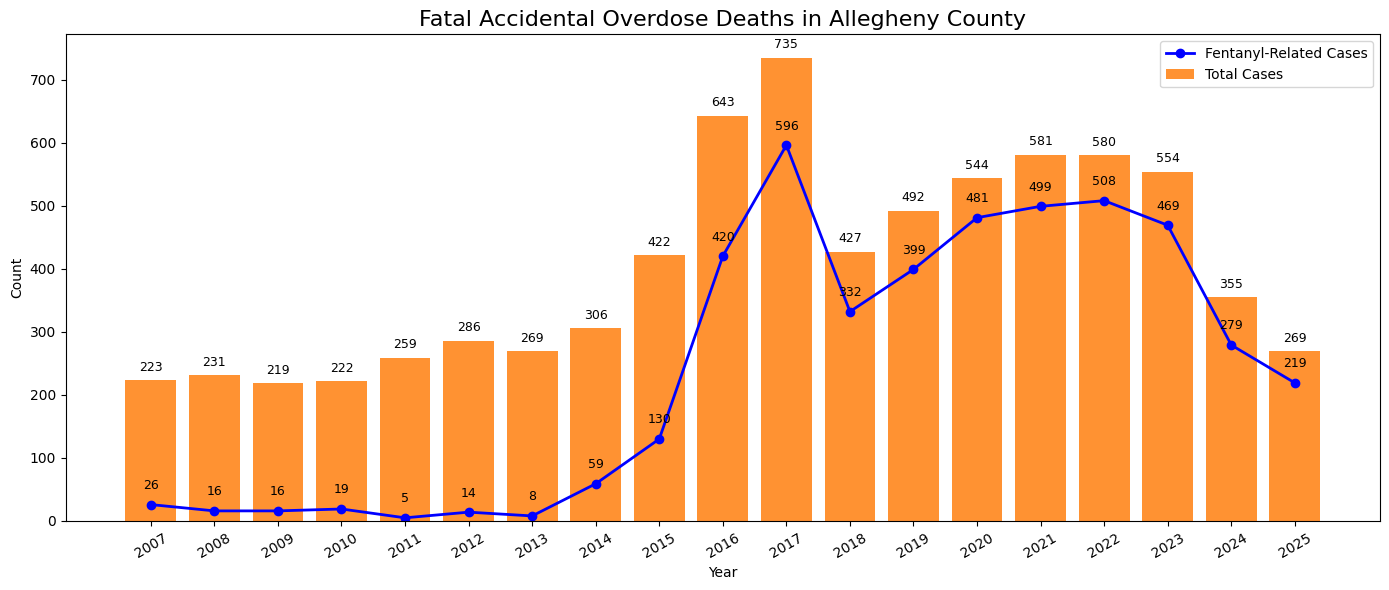

In [111]:
# visualize the rise in fentanyl-related cases

years = sorted(df.case_year.unique())
total_counts = df.groupby('case_year')['_id'].count().loc[years]
fent_counts = fentanyl_df.groupby('case_year')['_id'].count().reindex(years, fill_value=0)

fig, ax = plt.subplots(figsize=(14,6))

# bar chart (total cases)
bars = ax.bar(
    years,
    total_counts,
    color='C1',
    alpha=0.85,
    label='Total Cases'
)

# line chart (fentanyl cases)
ax.plot(
    years,
    fent_counts,
    color='blue',
    marker='o',
    linewidth=2,
    label='Fentanyl-Related Cases'
)

# add counts above bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 10,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# add counts to fentanyl line 
for x, y in zip(years, fent_counts):
    ax.text(
        x,
        y + 20,
        f'{int(y)}',
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_title('Fatal Accidental Overdose Deaths in Allegheny County', fontsize=16)
ax.set_ylabel('Count')
ax.set_xlabel('Year')

plt.xticks(years, rotation=30)

plt.legend()
plt.tight_layout()
plt.show()

In [67]:
# percentages of fentanyl-related cases per year
for year in years:
    print(year, '>', np.round(fentanyl_df.loc[fentanyl_df['case_year'] == year]._id.count()/df.loc[df['case_year'] == year]._id.count(),3))

2007 > 0.117
2008 > 0.069
2009 > 0.073
2010 > 0.086
2011 > 0.019
2012 > 0.049
2013 > 0.03
2014 > 0.193
2015 > 0.308
2016 > 0.653
2017 > 0.811
2018 > 0.778
2019 > 0.811
2020 > 0.884
2021 > 0.859
2022 > 0.876
2023 > 0.847
2024 > 0.786
2025 > 0.814


In [113]:
# % of fentanyl-related cases in the last 10 years
years_10 = ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']

total_cases_10 = df.loc[df.case_year.isin(years_10)]._id.count()
fent_cases_10 = fentanyl_df.loc[fentanyl_df.case_year.isin(years_10)]._id.count()

print('% of fentanyl-related cases in the last 10 years:', np.round(fent_cases_10/total_cases_10,3))

% of fentanyl-related cases in the last 10 years: 0.773


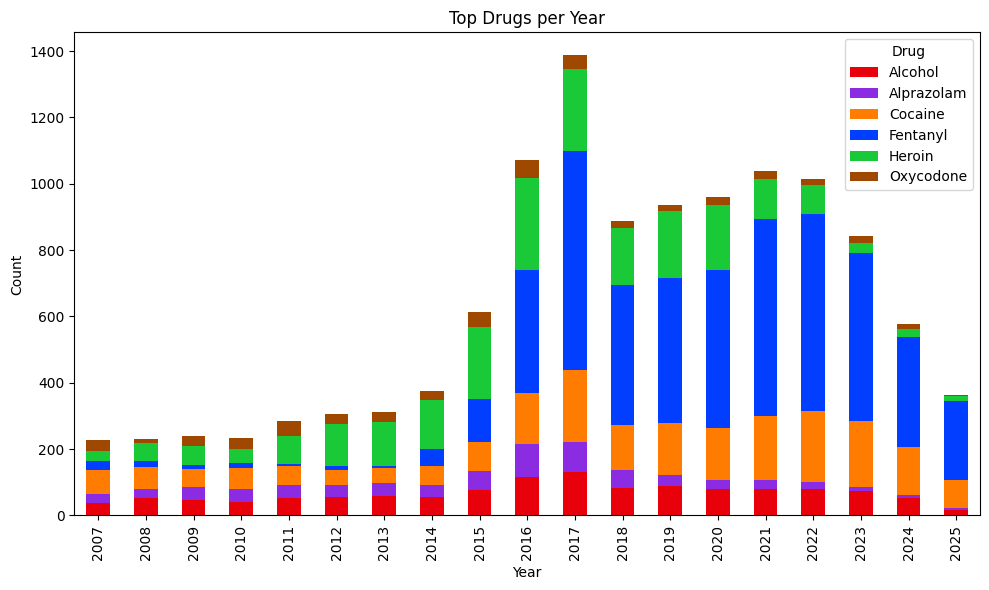

In [137]:
# stacked bar chart for top drugs

# pivot the counts long format back to wide
counts_wide = counts.pivot(
    index='case_year',
    columns='drug',
    values='count'
).fillna(0)

# plot
counts_wide.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=palette
)
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Top Drugs per Year')
plt.legend(title='Drug', loc='upper right')
plt.tight_layout()
plt.show()